# NLP Project 6 — News Classification

## Phân loại tin tức với TF-IDF + Linear SVM

Trong project này, ta xây dựng một hệ thống **multi-class text classification** để phân loại tin tức vào 4 nhóm:

- `sports`
- `business`
- `politics`
- `tech`

Pipeline chính:

```text
Raw news text
→ clean text
→ TF-IDF vectorization
→ Linear SVM
→ prediction: sports / business / politics / tech
```

Project này nối tiếp Spam Classifier và Sentiment Analysis, nhưng khó hơn vì output không còn là 2 class mà là nhiều class. Đây là dạng bài rất thực tế trong NLP truyền thống: phân loại bài báo, phân loại ticket hỗ trợ, phân loại email, phân loại nội dung website.

Mục tiêu của notebook là không chỉ “train được model”, mà còn hiểu rõ:

- Vì sao cần TF-IDF?
- Vì sao Linear SVM hợp với text?
- Cách đọc dataset từ nhiều format khác nhau.
- Cách đánh giá multi-class classification.
- Cách phân tích lỗi và xem từ quan trọng của từng class.
- Cách lưu model để dùng lại.

# 1. Mục tiêu học được sau project

Sau khi hoàn thành project này, bạn cần làm được:

1. Hiểu bài toán **News Topic Classification**.
2. Biết chọn dataset phù hợp: BBC News hoặc AG News.
3. Biết làm EDA cơ bản cho dữ liệu text.
4. Biết clean text ở mức hợp lý.
5. Biết dùng `TfidfVectorizer` để biến text thành vector.
6. Biết train `LinearSVC` cho multi-class classification.
7. Biết đánh giá model bằng:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion Matrix
8. Biết đọc `classification_report`.
9. Biết phân tích các bài bị dự đoán sai.
10. Biết xem top words/top n-grams quan trọng cho từng class.
11. Biết tune hyperparameter bằng `GridSearchCV`.
12. Biết save/load model bằng `joblib`.

Kết quả cuối cùng:

```text
Input : "The prime minister announced a new election policy."
Output: politics
```

```text
Input : "Apple released a new AI chip for mobile devices."
Output: tech
```

# 2. Nghiên cứu dataset

Project này có 2 dataset phổ biến.

## Option A — BBC News Dataset

BBC News Dataset có 2,225 bài báo thuộc 5 nhóm:

```text
business, entertainment, politics, sport, tech
```

Project của ta cần 4 nhóm:

```text
sports, business, politics, tech
```

Vì vậy, với BBC News Dataset, ta sẽ:

```text
sport → sports
business → business
politics → politics
tech → tech
entertainment → bỏ
```

Đây là lựa chọn tốt nhất nếu bạn muốn đúng 4 class của project.

---

## Option B — AG News Dataset

AG News có 4 class:

```text
World, Sports, Business, Sci/Tech
```

AG News rất lớn và train tốt. Tuy nhiên có một vấn đề:

```text
AG News không có class politics.
```

Class gần nhất là `World`, nhưng `World` không hoàn toàn giống `politics`. Nó có thể gồm tin thế giới, xã hội, ngoại giao, chiến tranh, chính sách, v.v.

Vì vậy:

- Nếu muốn đúng nhãn `sports/business/politics/tech`: dùng **BBC News**.
- Nếu muốn luyện pipeline với dataset lớn hơn: dùng **AG News**, nhưng cần ghi rõ rằng `World` được map gần đúng sang `politics`.

Trong notebook này, mình viết code hỗ trợ cả hai.

# 3. Cài đặt thư viện

Project dùng các thư viện quen thuộc:

- `pandas`: xử lý dữ liệu dạng bảng.
- `numpy`: xử lý số.
- `matplotlib`: vẽ biểu đồ.
- `scikit-learn`: TF-IDF, SVM, train/test split, metrics.
- `joblib`: lưu model.

Nếu chạy trên Google Colab hoặc máy local mà thiếu thư viện, chạy cell dưới đây.

In [ ]:
# Nếu thiếu thư viện, hãy bỏ dấu # để cài.
# !pip install pandas numpy matplotlib scikit-learn joblib

# 4. Import thư viện

In [1]:
from pathlib import Path
import re
import html
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 160)

# 5. Cấu trúc dataset

Bạn có thể tải dataset theo một trong các format sau.

## BBC dạng folder

```text
data/
└── bbc/
    ├── business/
    ├── entertainment/
    ├── politics/
    ├── sport/
    └── tech/
```

## BBC dạng CSV

```text
data/
└── bbc-text.csv
```

Thường có cột:

```text
category, text
```

## AG News dạng CSV

```text
data/
└── ag_news/
    ├── train.csv
    └── test.csv
```

Thường có format:

```text
Class Index, Title, Description
```

với mapping:

```text
1 = World
2 = Sports
3 = Business
4 = Sci/Tech
```

In [8]:
# Chọn dataset source:
# - 'bbc'
# - 'bbc_csv'
# - 'ag_news_csv'
# - 'demo' để chạy thử khi chưa tải dataset thật

BASE_DIR = Path.cwd().parent
DATASET_SOURCE = 'bbc'

BBC_FOLDER_DIR = BASE_DIR / 'data' / 'bbc'
BBC_CSV_PATH = BASE_DIR / 'data' / 'bbc-text.csv'

AG_NEWS_TRAIN_PATH = BASE_DIR / 'data' / 'ag_news' / 'train.csv'
AG_NEWS_TEST_PATH = BASE_DIR / 'data' / 'ag_news' / 'test.csv'

# Nếu dùng AG News, World không phải Politics 100%.
# Nhưng nếu muốn ép về 4 class của project, ta map World -> politics.
MAP_AG_WORLD_TO_POLITICS = True

# 6. Hàm đọc và chuẩn hóa dữ liệu

Mục tiêu là đưa mọi dataset về cùng format:

```text
text, label
```

Trong đó `label` chỉ gồm:

```text
sports, business, politics, tech
```

Hàm đọc dữ liệu cần xử lý các lỗi thường gặp:

- CSV có encoding khác nhau.
- Dataset có header hoặc không có header.
- BBC dạng folder `.txt`.
- Label `sport` cần đổi thành `sports`.
- AG News `Sci/Tech` cần đổi thành `tech`.
- AG News `World` có thể map sang `politics` nếu ta chấp nhận mapping gần đúng.

In [3]:
def normalize_label(label):
    label = str(label).strip().lower()
    mapping = {
        'sport': 'sports',
        'sports': 'sports',
        'business': 'business',
        'politics': 'politics',
        'politic': 'politics',
        'tech': 'tech',
        'technology': 'tech',
        'sci/tech': 'tech',
        'science/technology': 'tech',
        'world': 'politics' if MAP_AG_WORLD_TO_POLITICS else 'world'
    }
    return mapping.get(label, label)


def read_csv_with_fallback(path):
    encodings = ['utf-8', 'utf-8-sig', 'latin1']
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def load_bbc_from_folder(root_dir):
    rows = []
    wanted = {'business', 'politics', 'sport', 'sports', 'tech'}

    if not root_dir.exists():
        raise FileNotFoundError(f'Không tìm thấy folder: {root_dir}')

    for category_dir in root_dir.iterdir():
        if not category_dir.is_dir():
            continue

        raw_label = category_dir.name.strip().lower()
        if raw_label not in wanted:
            continue

        label = normalize_label(raw_label)

        for txt_file in category_dir.glob('*.txt'):
            try:
                text = txt_file.read_text(encoding='utf-8', errors='ignore')
            except Exception:
                text = txt_file.read_text(encoding='latin1', errors='ignore')

            rows.append({
                'text': text,
                'label': label,
                'source_file': str(txt_file)
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError('Không đọc được BBC folder. Hãy kiểm tra cấu trúc thư mục.')
    return df


def load_bbc_from_csv(csv_path):
    if not csv_path.exists():
        raise FileNotFoundError(f'Không tìm thấy file: {csv_path}')

    df = read_csv_with_fallback(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    label_col_candidates = ['category', 'label', 'class', 'target']
    text_col_candidates = ['text', 'content', 'article', 'description']

    label_col = next((c for c in label_col_candidates if c in df.columns), None)
    text_col = next((c for c in text_col_candidates if c in df.columns), None)

    if label_col is None or text_col is None:
        raise ValueError(f'Không tìm thấy cột label/text. Các cột hiện có: {df.columns.tolist()}')

    df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})
    df['label'] = df['label'].apply(normalize_label)

    wanted_labels = {'sports', 'business', 'politics', 'tech'}
    df = df[df['label'].isin(wanted_labels)].copy()
    return df


def load_ag_news_from_csv(train_path, test_path=None):
    if not train_path.exists():
        raise FileNotFoundError(f'Không tìm thấy file: {train_path}')

    def read_ag_file(path, split_name):
        try:
            df = pd.read_csv(path)
            lower_cols = [str(c).strip().lower() for c in df.columns]

            if any('class' in c for c in lower_cols):
                df.columns = lower_cols
                label_col = next(c for c in df.columns if 'class' in c or c in ['label', 'target'])
                title_col = next((c for c in df.columns if 'title' in c), None)
                desc_col = next((c for c in df.columns if 'description' in c or 'desc' in c), None)
            else:
                raise ValueError('No clear header')
        except Exception:
            df = pd.read_csv(path, header=None)
            if df.shape[1] < 3:
                raise ValueError('AG News CSV cần ít nhất 3 cột: class, title, description')
            df = df.iloc[:, :3]
            df.columns = ['class_index', 'title', 'description']
            label_col = 'class_index'
            title_col = 'title'
            desc_col = 'description'

        label_map = {
            1: 'world',
            2: 'sports',
            3: 'business',
            4: 'tech'
        }

        labels = df[label_col]
        if pd.api.types.is_numeric_dtype(labels):
            df['label'] = labels.map(label_map)
        else:
            df['label'] = labels.astype(str).str.strip().str.lower()
            df['label'] = df['label'].replace({
                '1': 'world',
                '2': 'sports',
                '3': 'business',
                '4': 'tech',
                'sci/tech': 'tech',
                'science/technology': 'tech'
            })

        df['label'] = df['label'].apply(normalize_label)

        title = df[title_col].fillna('') if title_col else ''
        desc = df[desc_col].fillna('') if desc_col else ''
        df['text'] = (title.astype(str) + ' ' + desc.astype(str)).str.strip()
        df['split'] = split_name
        return df[['text', 'label', 'split']]

    train_df = read_ag_file(train_path, 'train')
    dfs = [train_df]

    if test_path is not None and test_path.exists():
        dfs.append(read_ag_file(test_path, 'test'))

    return pd.concat(dfs, ignore_index=True)


def make_demo_dataset():
    # Dataset nhỏ để notebook chạy được khi chưa tải dataset thật.
    # Không dùng dataset demo để kết luận performance thật.
    samples = [
        ('The football team won the championship after a dramatic final match.', 'sports'),
        ('The coach praised the players after their victory in the league.', 'sports'),
        ('A tennis star reached the semi-final after a strong performance.', 'sports'),
        ('The basketball club signed a young defender for the new season.', 'sports'),
        ('Fans celebrated after the national team scored in extra time.', 'sports'),
        ('The striker returned from injury and scored two goals.', 'sports'),

        ('The company reported higher profits in the final quarter.', 'business'),
        ('Stock markets rose after investors reacted to the new earnings report.', 'business'),
        ('The bank announced a new loan program for small businesses.', 'business'),
        ('Oil prices increased due to strong demand from global markets.', 'business'),
        ('The startup raised new funding from international investors.', 'business'),
        ('Retail sales improved as consumer spending increased.', 'business'),

        ('The government introduced a new policy before the election.', 'politics'),
        ('Lawmakers debated the reform bill in parliament today.', 'politics'),
        ('The president met foreign leaders to discuss security issues.', 'politics'),
        ('A new campaign focused on education and healthcare reform.', 'politics'),
        ('The minister defended the decision during a press conference.', 'politics'),
        ('Voters will choose a new leader in the national election.', 'politics'),

        ('The software company released a new artificial intelligence tool.', 'tech'),
        ('Researchers developed a faster chip for mobile devices.', 'tech'),
        ('A cybersecurity firm warned users about a new online threat.', 'tech'),
        ('The smartphone maker announced an update for its operating system.', 'tech'),
        ('Scientists built a robot that can learn from human feedback.', 'tech'),
        ('Cloud computing services expanded with new data centers.', 'tech'),
    ]
    return pd.DataFrame(samples, columns=['text', 'label'])

# 7. Load dataset

Cell dưới đây sẽ cố đọc dataset thật. Nếu chưa có file dataset, notebook tự chuyển sang dataset demo nhỏ để bạn kiểm tra pipeline trước.

Khi làm project thật, hãy tải dataset rồi chạy lại.

In [ ]:
def load_dataset():
    if DATASET_SOURCE == 'bbc':
        return load_bbc_from_folder(BBC_FOLDER_DIR)
    elif DATASET_SOURCE == 'bbc_csv':
        return load_bbc_from_csv(BBC_CSV_PATH)
    elif DATASET_SOURCE == 'ag_news_csv':
        return load_ag_news_from_csv(AG_NEWS_TRAIN_PATH, AG_NEWS_TEST_PATH)
    elif DATASET_SOURCE == 'demo':
        return make_demo_dataset()
    else:
        raise ValueError("DATASET_SOURCE phải là 'bbc', 'bbc_csv', 'ag_news_csv', hoặc 'demo'")

try:
    df = load_dataset()
    print(f'Đọc dataset thành công từ source: {DATASET_SOURCE}')
except Exception as e:
    print('Không đọc được dataset thật.')
    print('Lý do:', e)
    print('Notebook sẽ dùng dataset demo nhỏ để kiểm tra pipeline.')
    df = make_demo_dataset()

df.head()

Đọc dataset từ source: bbc
Đọc dataset thành công từ source: bbc


,text,label,source_file
0,"Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $63...",business,c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\bbc\business\001.txt
1,Dollar gains on Greenspan speech\n\nThe dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US ...,business,c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\bbc\business\002.txt
2,Yukos unit buyer faces loan claim\n\nThe owners of embattled Russian oil giant Yukos are to ask the buyer of its former production unit to pay back a $900m ...,business,c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\bbc\business\003.txt
3,High fuel prices hit BA's profits\n\nBritish Airways has blamed high fuel prices for a 40% drop in profits.\n\nReporting its results for the three months to...,business,c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\bbc\business\004.txt
4,Pernod takeover talk lifts Domecq\n\nShares in UK drinks and food firm Allied Domecq have risen on speculation that it could be the target of a takeover by ...,business,c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\bbc\business\005.txt


# 8. EDA cơ bản cho text dataset

Ta cần kiểm tra:

- số dòng, số cột,
- missing values,
- phân phối class,
- duplicate text,
- độ dài text.

EDA giúp ta biết dataset có sạch không và có bị mất cân bằng class không.

In [10]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df[['text', 'label']].isna().sum())
print('\nLabel distribution:')
print(df['label'].value_counts())

Shape: (1839, 3)

Columns: ['text', 'label', 'source_file']

Missing values:
text     0
label    0
dtype: int64

Label distribution:
label
sports      511
business    510
politics    417
tech        401
Name: count, dtype: int64


In [11]:
df = df[['text', 'label']].copy()
df['text'] = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).apply(normalize_label)

wanted_labels = ['sports', 'business', 'politics', 'tech']
df = df[df['label'].isin(wanted_labels)].copy()

df = df[df['text'].str.len() > 0].copy()

before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
after = len(df)

print(f'Số dòng trước drop duplicate: {before}')
print(f'Số dòng sau drop duplicate : {after}')
print('\nLabel distribution sau clean:')
print(df['label'].value_counts())

Số dòng trước drop duplicate: 1839
Số dòng sau drop duplicate : 1758

Label distribution sau clean:
label
sports      505
business    503
politics    403
tech        347
Name: count, dtype: int64


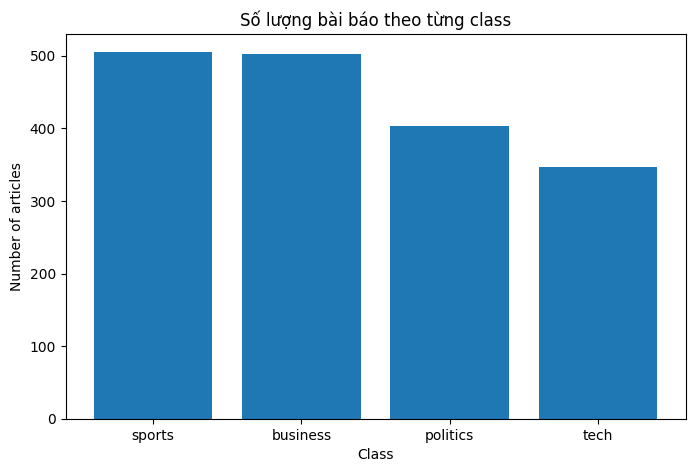

In [12]:
label_counts = df['label'].value_counts().reindex(wanted_labels)

plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title('Số lượng bài báo theo từng class')
plt.xlabel('Class')
plt.ylabel('Number of articles')
plt.show()

## Cách nhận xét class distribution

Nếu class distribution cân bằng, model dễ học công bằng hơn. Nếu một class quá nhiều và class khác quá ít, accuracy có thể cao nhưng model vẫn tệ ở class ít dữ liệu.

Vì vậy trong project này ta chú ý `macro F1-score`, không chỉ xem accuracy.

# 9. Phân tích độ dài văn bản

Text quá ngắn có thể thiếu thông tin. Text quá dài có thể chứa nhiều noise. Ta xem `text_length` và `word_count`.

In [13]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

df[['text_length', 'word_count']].describe()

,text_length,word_count
count,1758.000000,1758.000000
mean,2332.150171,394.902730
std,1347.855270,234.277638
min,502.000000,89.000000
25%,1513.000000,256.000000
50%,2093.500000,350.500000
75%,2880.750000,484.000000
max,25484.000000,4432.000000


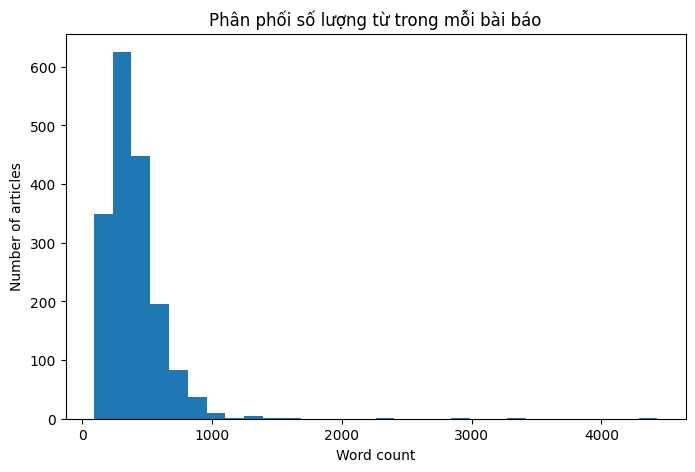

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=30)
plt.title('Phân phối số lượng từ trong mỗi bài báo')
plt.xlabel('Word count')
plt.ylabel('Number of articles')
plt.show()

In [15]:
df.sample(min(5, len(df)), random_state=RANDOM_STATE)[['label', 'text']]

,label,text
1125,sports,McClaren hails Boro's Uefa spirit\n\nMiddlesbrough boss Steve McClaren has praised the way his side have got to grips with European football after the 2-0 U...
1030,sports,Kewell waits as injury drags on\n\nLiverpool winger Harry Kewell is struggling to recover from his Achilles tendinitis problem and may not recover until Mar...
1450,tech,"T-Mobile bets on 'pocket office'\n\nT-Mobile has launched its latest ""pocket office"" third-generation (3G) device which also has built-in wi-fi - high-speed..."
1494,tech,"Warning over Windows Word files\n\nWriting a Microsoft Word document can be a dangerous business, according to document security firm Workshare.\n\nUp to 75..."
344,business,US to probe airline travel chaos\n\nThe US government is to investigate two airlines- US Airways and Delta Air Lines' Comair subsidiary - after travel chaos...


# 10. Text preprocessing

Với tiếng Anh, clean text ở mức vừa phải là đủ:

- lowercase,
- remove HTML entities,
- remove URL,
- remove email,
- remove ký tự lạ,
- xóa khoảng trắng thừa.

Không nên clean quá mạnh ngay từ đầu vì tin tức có nhiều tên riêng, tên công ty, số phiên bản sản phẩm, địa danh. Những thông tin này có thể hữu ích.

In [16]:
def clean_text(text):
    text = str(text)
    text = html.unescape(text)
    text = text.lower()

    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

example = "Apple's new AI chip is coming! Read more at https://example.com/news <br>"
print('Before:', example)
print('After :', clean_text(example))

Before: Apple's new AI chip is coming! Read more at https://example.com/news <br>
After : apple's new ai chip is coming read more at br


In [17]:
df['clean_text'] = df['text'].apply(clean_text)
df[['label', 'text', 'clean_text']].head()

,label,text,clean_text
0,business,"Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $63...",ad sales boost time warner profit quarterly profits at us media giant timewarner jumped 76 to 1 13bn 600m for the three months to december from 639m year ea...
1,business,Dollar gains on Greenspan speech\n\nThe dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US ...,dollar gains on greenspan speech the dollar has hit its highest level against the euro in almost three months after the federal reserve head said the us tra...
2,business,Yukos unit buyer faces loan claim\n\nThe owners of embattled Russian oil giant Yukos are to ask the buyer of its former production unit to pay back a $900m ...,yukos unit buyer faces loan claim the owners of embattled russian oil giant yukos are to ask the buyer of its former production unit to pay back a 900m 479m...
3,business,High fuel prices hit BA's profits\n\nBritish Airways has blamed high fuel prices for a 40% drop in profits.\n\nReporting its results for the three months to...,high fuel prices hit ba's profits british airways has blamed high fuel prices for a 40 drop in profits reporting its results for the three months to 31 dece...
4,business,Pernod takeover talk lifts Domecq\n\nShares in UK drinks and food firm Allied Domecq have risen on speculation that it could be the target of a takeover by ...,pernod takeover talk lifts domecq shares in uk drinks and food firm allied domecq have risen on speculation that it could be the target of a takeover by fra...


# 11. Train/Test Split

Ta dùng `stratify=y` để giữ tỷ lệ class trong train/test gần giống nhau.

Điểm rất quan trọng:

```text
Không fit TF-IDF trên toàn bộ dataset trước khi split.
```

Vì nếu fit TF-IDF trên cả test set, vocabulary của test đã bị lộ vào quá trình training. Đây là **data leakage**.

Cách đúng là dùng `Pipeline`:

```text
Train text → fit TF-IDF → fit Linear SVM
Test text  → transform bằng TF-IDF đã học từ train → predict
```

In [18]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])
print('\nTrain distribution:')
print(y_train.value_counts(normalize=True).round(3))
print('\nTest distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train size: 1406
Test size : 352

Train distribution:
label
sports      0.287
business    0.286
politics    0.229
tech        0.198
Name: proportion, dtype: float64

Test distribution:
label
sports      0.287
business    0.287
politics    0.230
tech        0.196
Name: proportion, dtype: float64


# 12. TF-IDF là gì?

Máy tính không hiểu trực tiếp text. Ta cần biến text thành vector số.

## Bag of Words

Ý tưởng đơn giản:

```text
Mỗi từ = một feature
Giá trị = số lần từ xuất hiện
```

Nhược điểm: từ phổ biến như `the`, `is`, `and` có thể xuất hiện nhiều nhưng không giúp phân loại.

## TF-IDF

TF-IDF kết hợp:

```text
TF-IDF = Term Frequency × Inverse Document Frequency
```

Trực giác:

- Từ xuất hiện nhiều trong một bài → quan trọng với bài đó.
- Nhưng nếu từ xuất hiện ở hầu hết mọi bài → không đặc biệt.
- Từ vừa xuất hiện trong bài, vừa không quá phổ biến toàn dataset → có trọng số cao.

Ví dụ:

- `goal`, `match`, `coach` → sports
- `profit`, `market`, `shares` → business
- `government`, `election`, `minister` → politics
- `software`, `chip`, `internet` → tech

# 13. Linear SVM là gì?

SVM tìm một ranh giới phân chia tốt giữa các class. Với text sau TF-IDF, mỗi bài báo là một vector rất nhiều chiều.

```text
article → [tfidf_word_1, tfidf_word_2, ..., tfidf_word_n]
```

Linear SVM học một **hyperplane** để tách các class.

Vì sao Linear SVM hợp với text?

- TF-IDF tạo vector rất nhiều chiều.
- Vector text thường sparse.
- Nhiều từ/ngram có khả năng phân biệt class tốt.
- Linear model thường là baseline mạnh cho text classification.

Với multi-class, `LinearSVC` dùng hướng **one-vs-rest**:

```text
sports vs rest
business vs rest
politics vs rest
tech vs rest
```

# 14. Build baseline model: TF-IDF + Linear SVM

Ta dùng `Pipeline` gồm:

```text
TfidfVectorizer → LinearSVC
```

Một số tham số đáng chú ý:

- `stop_words='english'`: bỏ stop words tiếng Anh.
- `ngram_range=(1, 2)`: dùng unigram và bigram.
- `min_df=1`: phù hợp để notebook demo chạy được; với dataset thật có thể thử `min_df=2`.
- `max_df=0.9`: bỏ từ xuất hiện trong quá nhiều document.
- `sublinear_tf=True`: giảm ảnh hưởng của từ lặp lại quá nhiều.
- `class_weight='balanced'`: hữu ích nếu class hơi lệch.

In [19]:
baseline_model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.9,
        sublinear_tf=True
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=5000
    ))
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

print('Train completed!')

Train completed!


# 15. Đánh giá model

Với multi-class classification, ta xem:

- `accuracy`: tỷ lệ dự đoán đúng tổng thể.
- `precision_macro`: trung bình precision theo class.
- `recall_macro`: trung bình recall theo class.
- `f1_macro`: trung bình F1 theo class.

`macro` nghĩa là mỗi class có trọng số ngang nhau. Điều này hữu ích khi dataset không cân bằng.

In [20]:
def evaluate_model(model, X_test, y_test, title='Model Evaluation'):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print('=' * 70)
    print(title)
    print('=' * 70)
    print(f'Accuracy        : {acc:.4f}')
    print(f'Precision macro : {precision_macro:.4f}')
    print(f'Recall macro    : {recall_macro:.4f}')
    print(f'F1 macro        : {f1_macro:.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

baseline_metrics = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    title='Baseline: TF-IDF + Linear SVM'
)

Baseline: TF-IDF + Linear SVM
Accuracy        : 0.9773
Precision macro : 0.9761
Recall macro    : 0.9778
F1 macro        : 0.9769

Classification report:
              precision    recall  f1-score   support

    business       0.97      0.95      0.96       101
    politics       0.96      0.98      0.97        81
      sports       1.00      1.00      1.00       101
        tech       0.97      0.99      0.98        69

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



## Cách đọc classification report

Ví dụ:

```text
              precision    recall  f1-score   support
business        0.95      0.94      0.95       100
politics        0.93      0.96      0.94        80
sports          0.99      0.98      0.99       100
tech            0.92      0.90      0.91        70
```

Ý nghĩa:

- `support`: số bài thật của class đó trong test set.
- `precision`: trong những bài model dự đoán là class đó, bao nhiêu bài đúng.
- `recall`: trong những bài thật thuộc class đó, model bắt được bao nhiêu bài.
- `f1-score`: cân bằng giữa precision và recall.

Nếu `recall` thấp → model bỏ sót nhiều bài của class đó.

Nếu `precision` thấp → model hay dự đoán nhầm bài khác vào class đó.

# 16. Confusion Matrix

Confusion Matrix cho biết model nhầm class nào với class nào.

Ví dụ thường gặp:

- `business` nhầm `tech`: bài nói về công ty công nghệ.
- `politics` nhầm `business`: bài nói về chính sách kinh tế.
- `tech` nhầm `business`: bài nói về Apple, Microsoft, startup, cổ phiếu.

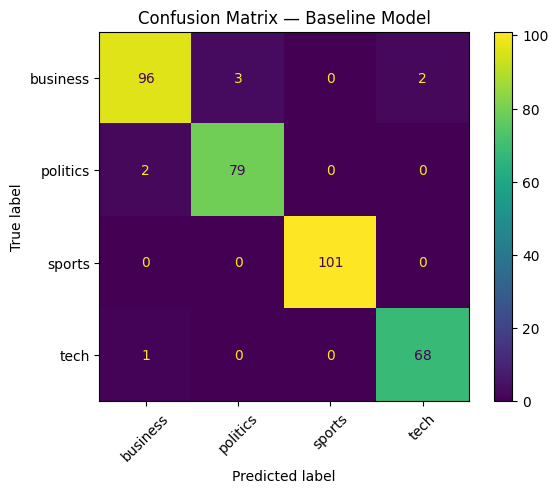

In [21]:
labels_order = sorted(y_test.unique())

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels_order,
    xticks_rotation=45
)

plt.title('Confusion Matrix — Baseline Model')
plt.show()

# 17. Error Analysis

Đây là bước rất quan trọng trong project thực tế.

Không chỉ nhìn metric, ta cần xem những bài model dự đoán sai để hiểu:

- Text có quá ngắn không?
- Bài có chủ đề lai giữa 2 class không?
- Label gốc có hợp lý không?
- Clean text có làm mất thông tin không?
- Model thiếu từ vựng quan trọng nào?

In [22]:
def get_error_analysis_df(model, X_test, y_test, n=20):
    y_pred = model.predict(X_test)
    errors = pd.DataFrame({
        'text': X_test.values,
        'true_label': y_test.values,
        'pred_label': y_pred
    })

    errors = errors[errors['true_label'] != errors['pred_label']].copy()
    errors['word_count'] = errors['text'].str.split().apply(len)
    return errors.head(n)

errors_df = get_error_analysis_df(baseline_model, X_test, y_test, n=20)
print('Số lỗi hiển thị:', len(errors_df))
errors_df

Số lỗi hiển thị: 8


,text,true_label,pred_label,word_count
45,card fraudsters 'targeting web' new safeguards on credit and debit card payments in shops has led fraudsters to focus on internet and phone payments an anti...,business,tech,405
162,golden rule 'intact' says ex aide chancellor gordon brown will meet his golden economic rule with a margin to spare according to his former chief economic a...,business,politics,307
184,china 'ripe' for media explosion asia is set to drive global media growth to 2008 and beyond with china and india filling the two top spots analysts have pr...,tech,business,592
186,call to overhaul uk state pension the uk pension system has been branded inadequate and too complex by a leading retirement think tank the pensions policy i...,business,politics,175
314,hatfield executives go on trial engineering firm balfour beatty and five railway managers are to go on trial for manslaughter over the hatfield rail crash i...,politics,business,212
315,us bank boss hails 'genius' smith us federal reserve chairman alan greenspan has given a speech at a scottish church in honour of the pioneering economist a...,business,politics,425
322,making your office work for you our mission to brighten up your working lives continues and this time we're taking a long hard look at your offices over the...,business,tech,889
335,report attacks defence spending the ministry of defence has been criticised over the soaring spending costs and growing delays of its top equipment projects...,politics,business,402


# 18. Xem từ quan trọng nhất cho từng class

Linear SVM có trọng số cho từng feature. Sau TF-IDF, feature là từ hoặc cụm từ.

Ta có thể xem top feature để hiểu model đang dựa vào từ nào.

Ví dụ kỳ vọng:

- `sports`: match, game, coach, goal, season
- `business`: market, shares, company, profit, bank
- `politics`: government, minister, election, policy, party
- `tech`: software, users, internet, mobile, computer

In [23]:
def show_top_features_per_class(model, top_n=15):
    tfidf = model.named_steps['tfidf']
    svm = model.named_steps['svm']

    feature_names = np.array(tfidf.get_feature_names_out())
    classes = svm.classes_
    coefs = svm.coef_

    rows = []
    for class_idx, class_name in enumerate(classes):
        top_indices = np.argsort(coefs[class_idx])[-top_n:][::-1]
        for idx in top_indices:
            rows.append({
                'class': class_name,
                'feature': feature_names[idx],
                'weight': coefs[class_idx][idx]
            })

    return pd.DataFrame(rows)

top_features_df = show_top_features_per_class(baseline_model, top_n=15)
top_features_df

,class,feature,weight
0,business,shares,1.545733
1,business,company,1.462601
2,business,bank,1.403217
3,business,firm,1.312488
4,business,market,1.308494
5,business,growth,1.208468
6,business,economy,1.202509
7,business,economic,1.123434
8,business,oil,1.102096
9,business,sales,1.069350


In [24]:
for class_name in baseline_model.named_steps['svm'].classes_:
    print('=' * 60)
    print('Class:', class_name)
    print('=' * 60)
    display(top_features_df[top_features_df['class'] == class_name][['feature', 'weight']].reset_index(drop=True))

Class: business


,feature,weight
0,shares,1.545733
1,company,1.462601
2,bank,1.403217
3,firm,1.312488
4,market,1.308494
5,growth,1.208468
6,economy,1.202509
7,economic,1.123434
8,oil,1.102096
9,sales,1.069350


Class: politics


,feature,weight
0,labour,1.732524
1,party,1.685411
2,mr,1.526454
3,election,1.349803
4,blair,1.320370
5,secretary,1.312692
6,government,1.295259
7,minister,1.228462
8,mps,1.086256
9,britain,0.999028


Class: sports


,feature,weight
0,match,1.387542
1,cup,1.274308
2,coach,1.206356
3,win,1.190077
4,club,1.168905
5,season,1.150131
6,team,1.147292
7,injury,1.091787
8,game,1.041748
9,rugby,1.007579


Class: tech


,feature,weight
0,computer,1.633530
1,users,1.611596
2,technology,1.553004
3,online,1.470552
4,software,1.400146
5,digital,1.298061
6,people,1.197336
7,net,1.191414
8,music,1.131131
9,internet,1.115372


# 19. Hyperparameter Tuning

Baseline model đã đủ tốt để học. Nhưng để project nghiêm túc hơn, ta tune một vài tham số.

Ta thử:

## TF-IDF

- `ngram_range`: unigram hoặc unigram + bigram.
- `min_df`: bỏ từ xuất hiện quá ít.
- `max_df`: bỏ từ xuất hiện quá nhiều.
- `max_features`: giới hạn số feature.

## Linear SVM

- `C`: điều khiển regularization.
  - C nhỏ → regularization mạnh → model đơn giản hơn.
  - C lớn → regularization yếu → model fit train mạnh hơn.

Ta dùng `f1_macro` làm scoring vì đây là multi-class classification.

In [25]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2],
    'tfidf__max_df': [0.85, 0.95],
    'tfidf__max_features': [5000, 10000, None],
    'svm__C': [0.5, 1.0, 2.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best CV f1_macro:', grid_search.best_score_)
print('Best params:')
print(grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best CV f1_macro: 0.9817622422791455
Best params:
{'svm__C': 2.0, 'tfidf__max_df': 0.95, 'tfidf__max_features': None, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}


In [26]:
best_model = grid_search.best_estimator_
best_metrics = evaluate_model(best_model, X_test, y_test, title='Tuned Model: TF-IDF + Linear SVM')

Tuned Model: TF-IDF + Linear SVM
Accuracy        : 0.9773
Precision macro : 0.9761
Recall macro    : 0.9778
F1 macro        : 0.9769

Classification report:
              precision    recall  f1-score   support

    business       0.97      0.95      0.96       101
    politics       0.96      0.98      0.97        81
      sports       1.00      1.00      1.00       101
        tech       0.97      0.99      0.98        69

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



# 20. So sánh baseline và tuned model

In [27]:
results_df = pd.DataFrame([
    {'model': 'Baseline TF-IDF + Linear SVM', **baseline_metrics},
    {'model': 'Tuned TF-IDF + Linear SVM', **best_metrics}
])

results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline TF-IDF + Linear SVM,0.977273,0.976135,0.977828,0.976936
1,Tuned TF-IDF + Linear SVM,0.977273,0.976135,0.977828,0.976936


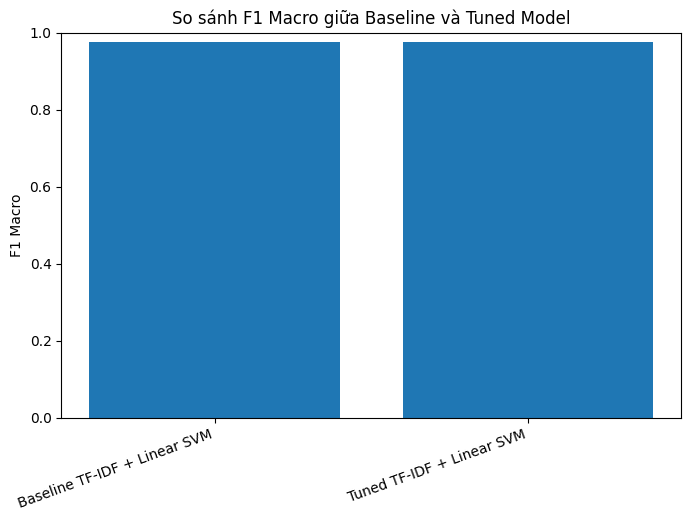

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['f1_macro'])
plt.title('So sánh F1 Macro giữa Baseline và Tuned Model')
plt.ylabel('F1 Macro')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.show()

# 21. Chọn final model

Ta chọn model dựa trên `f1_macro` trên test set.

In [29]:
if best_metrics['f1_macro'] >= baseline_metrics['f1_macro']:
    final_model = best_model
    final_model_name = 'Tuned TF-IDF + Linear SVM'
else:
    final_model = baseline_model
    final_model_name = 'Baseline TF-IDF + Linear SVM'

print('Final model:', final_model_name)

Final model: Tuned TF-IDF + Linear SVM


# 22. Predict tin mới

Khi predict dữ liệu mới, ta cần clean text giống lúc training.

In [30]:
def predict_news_category(text, model=final_model):
    cleaned = clean_text(text)
    return model.predict([cleaned])[0]

sample_news = [
    'The football club signed a new striker before the Champions League match.',
    'The company reported record profits and its shares rose in early trading.',
    'The prime minister announced a new policy before the national election.',
    'Researchers released a new artificial intelligence model for smartphones.'
]

for text in sample_news:
    print('Text      :', text)
    print('Prediction:', predict_news_category(text))
    print('-' * 80)

Text      : The football club signed a new striker before the Champions League match.
Prediction: sports
--------------------------------------------------------------------------------
Text      : The company reported record profits and its shares rose in early trading.
Prediction: business
--------------------------------------------------------------------------------
Text      : The prime minister announced a new policy before the national election.
Prediction: politics
--------------------------------------------------------------------------------
Text      : Researchers released a new artificial intelligence model for smartphones.
Prediction: tech
--------------------------------------------------------------------------------


# 23. Decision score của Linear SVM

`LinearSVC` không có `predict_proba()` trực tiếp. Nó dùng `decision_function()`.

Class có decision score cao nhất sẽ được chọn.

Điều này không phải xác suất, nhưng giúp ta xem model nghiêng về class nào.

In [31]:
def predict_with_scores(text, model=final_model):
    cleaned = clean_text(text)
    scores = model.decision_function([cleaned])[0]
    classes = model.named_steps['svm'].classes_

    return pd.DataFrame({
        'class': classes,
        'decision_score': scores
    }).sort_values('decision_score', ascending=False)

hard_text = 'The government is investing in new technology companies to improve the economy.'
print(hard_text)
predict_with_scores(hard_text)

The government is investing in new technology companies to improve the economy.


,class,decision_score
0,business,0.099579
3,tech,-0.353895
1,politics,-0.780783
2,sports,-0.992452


Ví dụ trên khó vì có nhiều tín hiệu:

- `government` → politics
- `technology companies` → tech
- `economy` → business

Trong thực tế, nhiều bài báo không thuộc một chủ đề “sạch” 100%. Đây là lý do cần error analysis.

# 24. Save model

Model được lưu bằng `joblib`.

Lưu ý:

- Pipeline đã chứa TF-IDF và Linear SVM.
- Hàm `clean_text` không nằm trong file model, nên khi deploy cần copy hàm này hoặc viết thành module riêng.

In [34]:
MODEL_DIR = Path.cwd().parent / 'models' / 'news_classification'
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / 'news_classifier_tfidf_linear_svm.joblib'
joblib.dump(final_model, model_path)

print('Đã lưu model tại:', model_path)

Đã lưu model tại: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\news_classification\news_classifier_tfidf_linear_svm.joblib


In [57]:
loaded_model = joblib.load(model_path)

new_text = 'Iphone 18 promax will be released next month with advanced AI features.'
print('Prediction from loaded model:', predict_news_category(new_text, model=loaded_model))

Prediction from loaded model: tech


# 25. Báo cáo kết quả ngắn

Khi đưa project lên GitHub, README nên có:

1. Problem statement
2. Dataset
3. Preprocessing
4. Model
5. Metrics
6. Confusion Matrix
7. Error Analysis
8. Limitations
9. Next Steps

In [36]:
report_df = results_df.copy()
for col in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    report_df[col] = report_df[col].round(4)

report_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline TF-IDF + Linear SVM,0.9773,0.9761,0.9778,0.9769
1,Tuned TF-IDF + Linear SVM,0.9773,0.9761,0.9778,0.9769


# 26. Hạn chế của project

## 1. TF-IDF không hiểu ngữ nghĩa sâu

TF-IDF chủ yếu dựa trên từ xuất hiện, không hiểu ngữ cảnh như BERT/Transformer.

Ví dụ:

```text
Apple stock rose after the new iPhone launch.
```

Câu này vừa có business vừa có tech.

## 2. Linear SVM không trả xác suất trực tiếp

`LinearSVC` trả decision score, không phải probability. Nếu cần probability, có thể dùng:

- `CalibratedClassifierCV`
- Logistic Regression

## 3. AG News không có politics đúng nghĩa

Nếu dùng AG News, class `World` chỉ gần với politics, không phải politics thuần.

## 4. BBC dataset khá cũ

BBC News Dataset phổ biến cho học tập, nhưng dữ liệu từ 2004–2005. Chủ đề tech/news hiện nay có nhiều từ mới hơn.

# 27. Hướng nâng cấp project

## Level 1 — ML truyền thống

- So sánh với Logistic Regression.
- So sánh với Multinomial Naive Bayes.
- Thử `char n-gram`.
- Tune thêm `C`, `max_features`, `ngram_range`.
- Dùng `CalibratedClassifierCV` nếu cần probability.

## Level 2 — Mini production

- Save model.
- Tạo FastAPI endpoint `/predict`.
- Tạo Streamlit UI.
- Cho user paste bài báo và trả về category.

## Level 3 — Deep Learning / Transformer

- Word2Vec/GloVe + classifier.
- LSTM/GRU.
- Fine-tune DistilBERT hoặc BERT.
- So sánh Transformer với TF-IDF + SVM.

# 28. Bài tập tự luyện

Không có đáp án kèm theo để bạn tự luyện trước.

## Bài 1

Thay `ngram_range=(1, 2)` thành `(1, 1)`. So sánh F1 macro.

## Bài 2

Thử bỏ `stop_words='english'`. Model tốt hơn hay tệ hơn?

## Bài 3

Thử `max_features=3000`, `5000`, `10000`. Số feature ảnh hưởng thế nào?

## Bài 4

Tìm 10 bài model dự đoán sai. Viết nhận xét nguyên nhân sai.

## Bài 5

Train thêm Logistic Regression và so sánh với Linear SVM.

## Bài 6

Tạo một file `app.py` bằng Streamlit để nhập một đoạn news text và trả về category.

# 29. Tổng kết

Project này đã hoàn thành pipeline:

```text
News text
→ clean text
→ TF-IDF vectorization
→ Linear SVM training
→ evaluation
→ confusion matrix
→ error analysis
→ feature interpretation
→ hyperparameter tuning
→ save model
→ predict new text
```

Kiến thức cần nhớ:

1. Text phải được biến thành vector số trước khi đưa vào model.
2. TF-IDF giúp từ quan trọng có trọng số cao hơn từ quá phổ biến.
3. Linear SVM là baseline mạnh cho text classification.
4. Với multi-class classification, nên xem `macro F1-score`, không chỉ accuracy.
5. Confusion Matrix và Error Analysis giúp hiểu model sai ở đâu.
6. BBC News phù hợp hơn AG News nếu muốn đúng class `politics`.
7. AG News lớn hơn, nhưng `World` không phải politics đúng nghĩa.

Đây là một project NLP ML-based rất tốt cho portfolio beginner/intermediate vì có đủ pipeline thực tế, không chỉ train model đơn giản.